In [110]:
!mamba install pandas matplotlib numpy seaborn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.8326999999992549 seconds
All requested packages already installed.


In [111]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

raw_data_path = PROJECT_ROOT / "data" / "raw"
processed_data_path = PROJECT_ROOT / "data" / "processed"
fig_path = PROJECT_ROOT / "reports" / "figures"

print("Current directory:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Raw data exists:", raw_data_path.exists())
print("Processed data exists:", processed_data_path.exists())
print("Figures folder exists:", fig_path.exists())

Current directory: /drive/notebooks/cind-820-learning-analytics/notebooks
Project root: /drive/notebooks/cind-820-learning-analytics
Raw data exists: True
Processed data exists: True
Figures folder exists: True


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [113]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
/drive/notebooks/cind-820-learning-analytics/notebooks


In [114]:
print("\nContents of current folder:")
print(os.listdir("."))

print("\nContents of parent folder:")
print(os.listdir(".."))


Contents of current folder:
['oulad_eda.ipynb', 'oulad_modelling.ipynb']

Contents of parent folder:
['README.md', 'data', 'eda', 'notebooks', 'reports', 'requirements.txt', 'scripts']


In [115]:
student_info = pd.read_csv(raw_data_path / "studentInfo.csv")
student_assessment = pd.read_csv(raw_data_path / "studentAssessment.csv")
assessments = pd.read_csv(raw_data_path / "assessments.csv")
vle = pd.read_csv(raw_data_path / "vle.csv")
courses = pd.read_csv(raw_data_path / "courses.csv")
student_registration = pd.read_csv(raw_data_path / "studentRegistration.csv")

In [116]:
datasets = {
    "student_info": student_info,
    "student_assessment": student_assessment,
    "assessments": assessments,
    "vle": vle,
    "courses": courses,
    "student_registration": student_registration
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("shape:", df.shape)
    print(df.head(2))


student_info
shape: (32593, 12)
  code_module code_presentation  id_student gender               region  \
0         AAA             2013J       11391      M  East Anglian Region   
1         AAA             2013J       28400      F             Scotland   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification   20-30%    35-55                     0               60   

  disability final_result  
0          N         Pass  
1          N         Pass  

student_assessment
shape: (173912, 5)
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0

assessments
shape: (206, 6)
  code_module code_presentation  id_assessment assessment_type  date  weight
0         AAA             2013J           1752             TMA  19.0    10.0
1    

In [117]:
assessment_merged = student_assessment.merge(
    assessments,
    on="id_assessment",
    how="left"
)

assessment_features = assessment_merged.groupby(
    ["id_student", "code_module", "code_presentation"],
    as_index=False
).agg(
    mean_score=("score", "mean"),
    total_assessments=("id_assessment", "count"),
    mean_weight=("weight", "mean")
)

assessment_features.head()

,id_student,code_module,code_presentation,mean_score,total_assessments,mean_weight
0,6516,AAA,2014J,61.800000,5,20.000000
1,8462,DDD,2013J,87.666667,3,13.333333
2,8462,DDD,2014J,86.500000,4,12.500000
3,11391,AAA,2013J,82.000000,5,20.000000
4,23629,BBB,2013B,82.500000,4,6.250000


In [118]:
df = student_info.merge(
    assessment_features,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

print(df.shape)
df.head()

(32593, 15)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_assessments,mean_weight
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,20.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,20.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,20.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,20.0


In [119]:
print(df.columns.tolist())
print(df["final_result"].value_counts(dropna=False))
print(df[["mean_score", "total_assessments", "mean_weight"]].isna().sum())

['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'mean_score', 'total_assessments', 'mean_weight']
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64
mean_score           6773
total_assessments    6750
mean_weight          6750
dtype: int64


In [120]:
df.to_csv(processed_data_path / "oulad_student_level.csv", index=False)

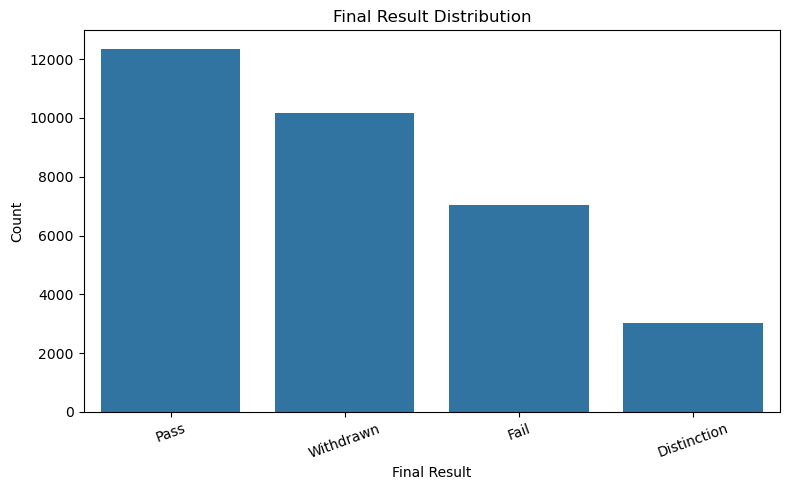

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="final_result", order=df["final_result"].value_counts().index)
plt.title("Final Result Distribution")
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(fig_path / "correlation_heatmap.png")
plt.show()

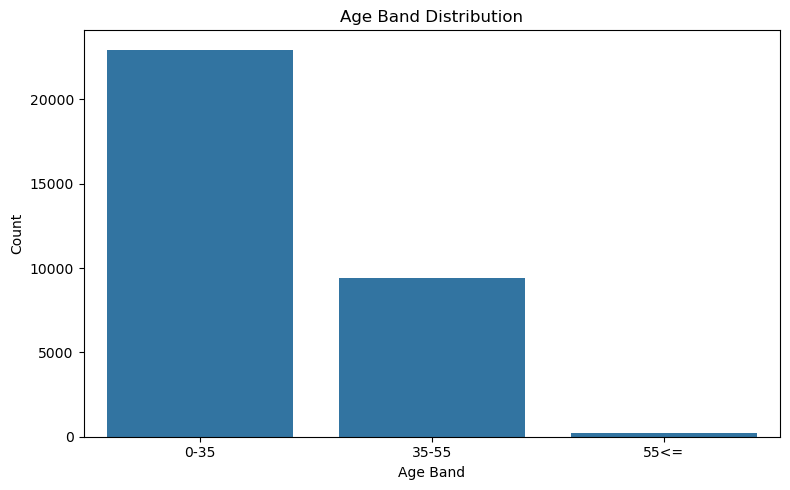

In [122]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="age_band", order=df["age_band"].value_counts().index)
plt.title("Age Band Distribution")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_path / "age_band_distribution.png")
plt.show()

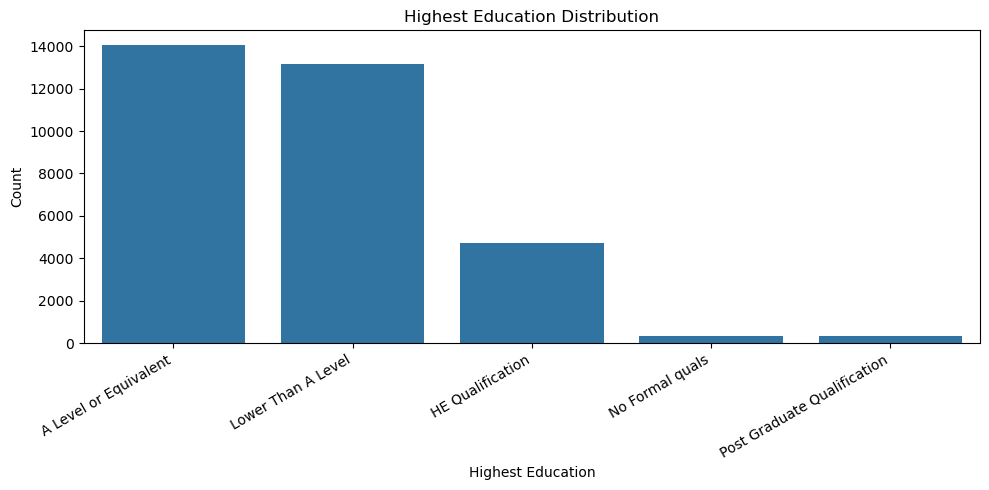

In [123]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="highest_education", order=df["highest_education"].value_counts().index)
plt.title("Highest Education Distribution")
plt.xlabel("Highest Education")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(fig_path / "highest_education_distribution.png")
plt.show()

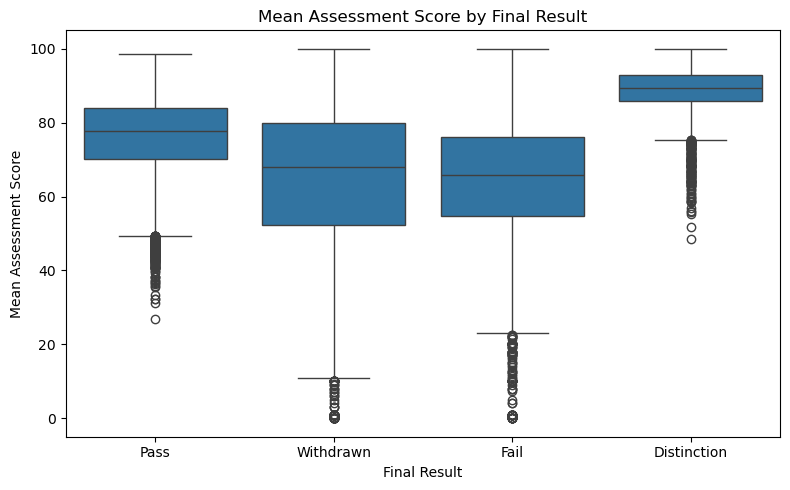

In [124]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="final_result", y="mean_score")
plt.title("Mean Assessment Score by Final Result")
plt.xlabel("Final Result")
plt.ylabel("Mean Assessment Score")
plt.tight_layout()
plt.savefig(fig_path / "mean_score_by_final_result.png")
plt.show()

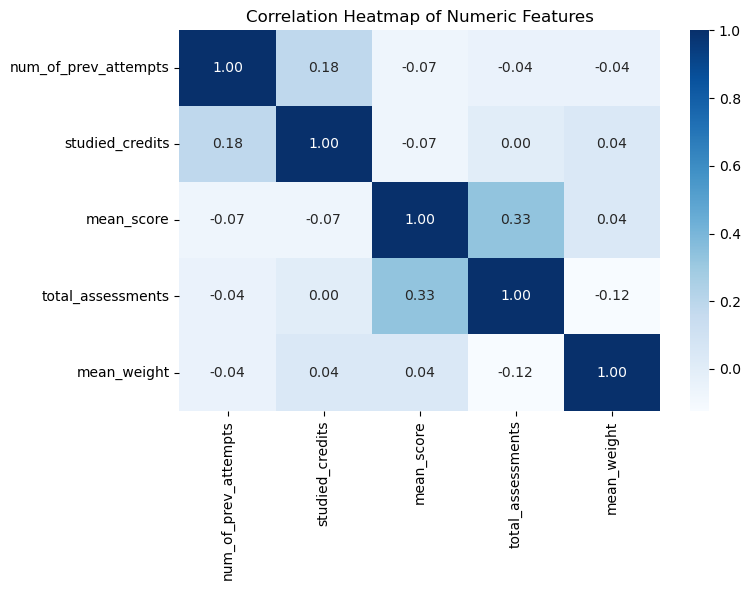

In [125]:
numeric_cols = [
    "num_of_prev_attempts",
    "studied_credits",
    "mean_score",
    "total_assessments",
    "mean_weight"
]

corr = df[numeric_cols].corr()
corr.to_csv(processed_data_path / "correlation_matrix.csv")
corr

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(fig_path / "correlation_heatmap.png")
plt.show()


In [126]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nPreview:")
display(df.head())

Shape: (32593, 15)

Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'mean_score', 'total_assessments', 'mean_weight']

Data types:
code_module                 str
code_presentation           str
id_student                int64
gender                      str
region                      str
highest_education           str
imd_band                    str
age_band                    str
num_of_prev_attempts      int64
studied_credits           int64
disability                  str
final_result                str
mean_score              float64
total_assessments       float64
mean_weight             float64
dtype: object

Preview:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_assessments,mean_weight
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,20.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,20.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,20.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,20.0


In [127]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
mean_score,6773,20.78
total_assessments,6750,20.71
mean_weight,6750,20.71
imd_band,1111,3.41
code_module,0,0.00
code_presentation,0,0.00
id_student,0,0.00
gender,0,0.00
region,0,0.00
highest_education,0,0.00


In [128]:
missing_summary.to_csv(processed_data_path / "missing_summary.csv")

In [129]:
numeric_summary = df.describe(include=[np.number]).T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.000000,590310.0,644453.000000,2716795.0
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.000000,0.0,0.000000,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.000000,60.0,120.000000,655.0
mean_score,25820.0,72.768254,16.374997,0.0,64.666667,76.0,84.545455,100.0
total_assessments,25843.0,6.729559,3.771381,1.0,4.000000,7.0,10.000000,14.0
mean_weight,25843.0,13.350761,8.823415,0.0,8.333333,9.9,20.000000,100.0


In [130]:
numeric_summary.to_csv(processed_data_path / "numeric_summary.csv")

In [131]:
categorical_vars = ["final_result", "age_band", "highest_education", "gender", "region"]

for col in categorical_vars:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- final_result ---
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

--- age_band ---
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

--- highest_education ---
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

--- gender ---
gender
M    17875
F    14718
Name: count, dtype: int64

--- region ---
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64


In [132]:
for col in categorical_vars:
    freq = df[col].value_counts(dropna=False).reset_index()
    freq.columns = [col, "count"]
    freq.to_csv(processed_data_path / f"{col}_frequency.csv", index=False)

In [133]:
dup_count = df.duplicated(subset=["id_student", "code_module", "code_presentation"]).sum()
print("Duplicate student-module-presentation rows:", dup_count)

Duplicate student-module-presentation rows: 0


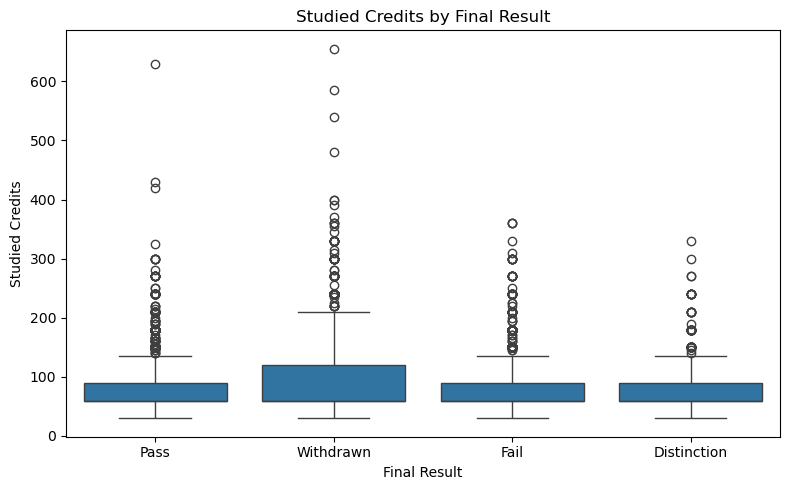

In [134]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="final_result", y="studied_credits")
plt.title("Studied Credits by Final Result")
plt.xlabel("Final Result")
plt.ylabel("Studied Credits")
plt.tight_layout()
plt.savefig(fig_path / "studied_credits_by_final_result.png", dpi=300, bbox_inches="tight")
plt.show()

In [135]:
df.to_csv(processed_data_path / "oulad_student_level.csv", index=False)